
#**19-modul. Unsupervised learning. Clustering**
# 19.8. Modul boʻyicha yakuniy amaliy vazifa. Mijozlarni xarajat turlariga qarab segmentlash

**Ushbu vazifa orqali siz:**

✔️ klasterlash;

✔️ maʼlumotlarni normallashtirish;

✔️ klaster tahlili;

✔️ vizualizatsiya kabi real data sayns loyihalari uchun zarur texnik ko‘nikmalarga ega bo‘lasiz.

## **Dataset: Wholesale Customers Data**  
- **Manba:** [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets/wholesale+customers)  
- **Hajmi:** **22 KB**
- **Format:** CSV  
- **Tavsif:** bu dataset **ulgurji savdo mijozlarini** xarajatlar bo‘yicha klasterlash uchun ishlatiladi.  
  U quyidagi xarajat kategoriyalarini o‘z ichiga oladi:  
  - **channel** (mijoz turi: 1 – HoReCa (mehmonxona, restoran, kafelar) yoki 2 – chakana savdo)  
  - **region** (hudud: 1 – Lisbon, 2 – Oporto, 3 – boshqa)  
  - **fresh** (yangi mahsulotlarga sarf qilingan summa)  
  - **milk** (sut mahsulotlariga sarf qilingan summa)  
  - **grocery** (oziq-ovqat mahsulotlariga sarf qilingan summa)  
  - **frozen** (muzlatilgan mahsulotlarga sarf qilingan summa)  
  - **Detergents_Paper** (kimyoviy tozalash va qog‘oz mahsulotlari)  
  - **delicassen** (delikates mahsulotlar)  

---

### **Vazifa: mijozlarni xarajat turlariga qarab segmentlash**  
Maqsad – **mijozlarni xarajat qiladigan mahsulotlar bo‘yicha klasterlash va marketologlarga tavsiyalar berish**  

---

### **Klasterlash bosqichlari**  
1) **Maʼlumotlarni tayyorlash**  
   - `Channel` va `Region` ustunlarini olib tashlang yoki kodlang.  
   - Har bir xarajat ustunini **normalizatsiya qiling**.  

2) **K-means klasterlashni amalga oshirish**  
   - K-means yordamida mijozlarni **xarajat qilish odatlari** bo‘yicha segmentlarga ajrating.  

3) **Natijalarni vizualizatsiya qilish**  
   - **Pairplot yoki scatter plot** yordamida klasterlarni ko‘rsating.  
   - Har bir segmentning xarajatlar bo‘yicha o‘rtacha qiymatini diagrammada aks ettiring.

---

###*** ESLATMA**: *Ushbu amaliy vazifada siz oʻtmagan mavzulardan ham savollar va vazifalar boʻlishi mumkin! Bu savollarni mustaqil oʻrganishingiz kerak boʻladi. Bunday vazifalar mustaqil izlanish koʻnikmangizni oshirish uchun tayyorlandi!*

In [16]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans


In [17]:

df = pd.read_csv("https://raw.githubusercontent.com/alishermutalov/praktikum-datasets/refs/heads/praktikum/Wholesale_customers_data.csv")
df.head()


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


# 1. Maʼlumotlarni tayyorlash

1. Channel va Region ustunlarini olib tashlang yoki kodlang.
2. Har bir xarajat ustunini normalizatsiya qiling.

In [18]:
df = df.drop(columns = ["Channel", "Region"])
df.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,12669,9656,7561,214,2674,1338
1,7057,9810,9568,1762,3293,1776
2,6353,8808,7684,2405,3516,7844
3,13265,1196,4221,6404,507,1788
4,22615,5410,7198,3915,1777,5185


In [19]:
df.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,12669,9656,7561,214,2674,1338
1,7057,9810,9568,1762,3293,1776
2,6353,8808,7684,2405,3516,7844
3,13265,1196,4221,6404,507,1788
4,22615,5410,7198,3915,1777,5185


In [20]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)
df = pd.DataFrame(data=scaled_data, columns=df.columns)
df.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,0.052933,0.523568,-0.041115,-0.589367,-0.043569,-0.066339
1,-0.391302,0.544458,0.170318,-0.270136,0.086407,0.089151
2,-0.447029,0.408538,-0.028157,-0.137536,0.133232,2.243293
3,0.100111,-0.624020,-0.392977,0.687144,-0.498588,0.093411
4,0.840239,-0.052396,-0.079356,0.173859,-0.231918,1.299347


# 2 K-means klasterlashni amalga oshirish

K-means yordamida mijozlarni xarajat qilish odatlari bo‘yicha segmentlarga ajrating.

In [21]:
X_train, X_test = train_test_split(df, train_size=0.8, random_state=42)

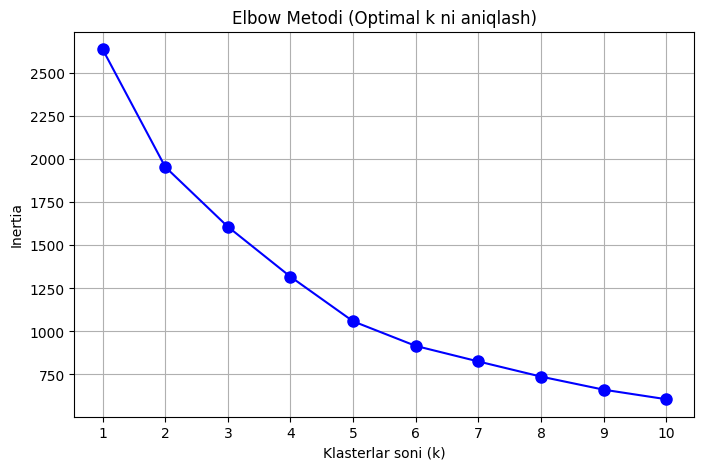

In [22]:
# 1-10 oraliqdagi k qiymatlari uchun Inertia hisoblash
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df)  # scaler'dan o'tgan df
    inertia.append(kmeans.inertia_)

# Grafikni chizish
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, 'bo-', markersize=8)
plt.title("Elbow Metodi (Optimal k ni aniqlash)")
plt.xlabel("Klasterlar soni (k)")
plt.ylabel("Inertia")
plt.xticks(K_range)
plt.grid(True)
plt.show()

In [23]:
model = KMeans(init = "random", n_clusters = 2, n_init = 15)
model.fit(X_train)


KMeans(init='random', n_clusters=2, n_init=15)

In [24]:
# 1. Asl (scale qilinmagan) dataframe nusxasini olamiz
df_analysis = pd.read_csv("https://raw.githubusercontent.com/alishermutalov/praktikum-datasets/refs/heads/praktikum/Wholesale_customers_data.csv")
df_analysis = df_analysis.drop(columns=["Channel", "Region"])

# 2. Modellangan klaster yorliqlarini biriktiramiz
# (Agar modelni butun df uchun o'qitgan bo'lsangiz: model.predict(df))
df_analysis['Cluster'] = model.predict(df)

# 3. Har bir klaster bo'yicha o'rtacha xarajatlarni hisoblaymiz
cluster_means = df_analysis.groupby('Cluster').mean()
print(cluster_means)

                Fresh          Milk       Grocery       Frozen  \
Cluster                                                          
0        16323.517241  24778.103448  32786.586207  5869.034483   
1        11695.253041   4456.914842   6198.907543  2874.569343   

         Detergents_Paper   Delicassen  
Cluster                                 
0            15204.655172  4900.344828  
1             2011.975669  1286.698297  


<Figure size 1200x600 with 0 Axes>

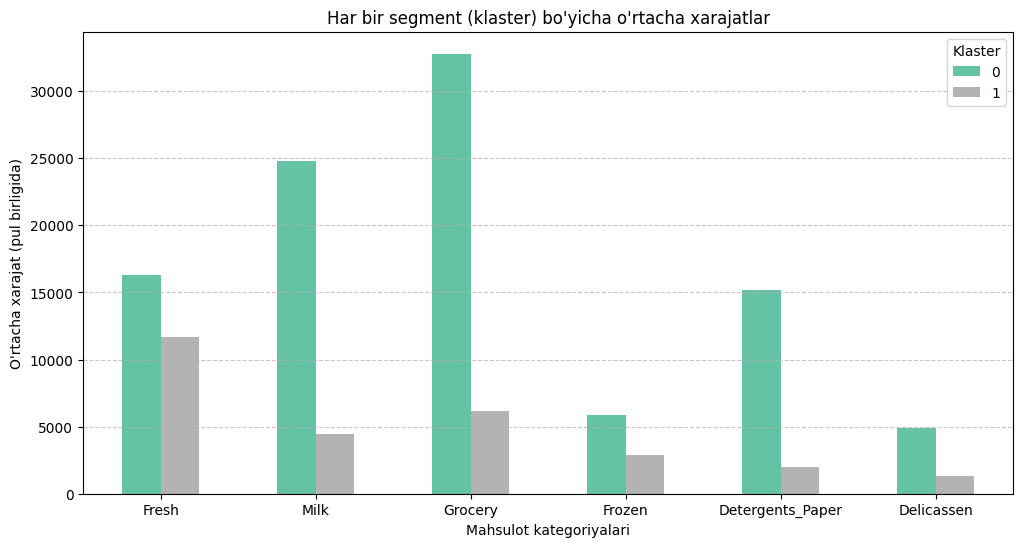

In [25]:
# Klasterlar bo'yicha o'rtacha xarajatlar diagrammasi
plt.figure(figsize=(12, 6))
ax = cluster_means.T.plot(kind='bar', figsize=(12, 6), colormap='Set2')

plt.title("Har bir segment (klaster) bo'yicha o'rtacha xarajatlar")
plt.xlabel("Mahsulot kategoriyalari")
plt.ylabel("O'rtacha xarajat (pul birligida)")
plt.xticks(rotation=0)
plt.legend(title="Klaster")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [26]:
model.cluster_centers_

array([[ 0.10669736,  2.6400559 ,  2.74593981,  0.59342072,  2.72608263,
         1.3062197 ],
       [-0.04885757, -0.18814509, -0.18555686, -0.07633711, -0.17510725,
        -0.08253445]])

In [27]:
model.labels_

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

# 3 Natijalarni vizualizatsiya qilish

1. Pairplot yoki scatter plot yordamida klasterlarni ko‘rsating.
2. Har bir segmentning xarajatlar bo‘yicha o‘rtacha qiymatini diagrammada aks ettiring.

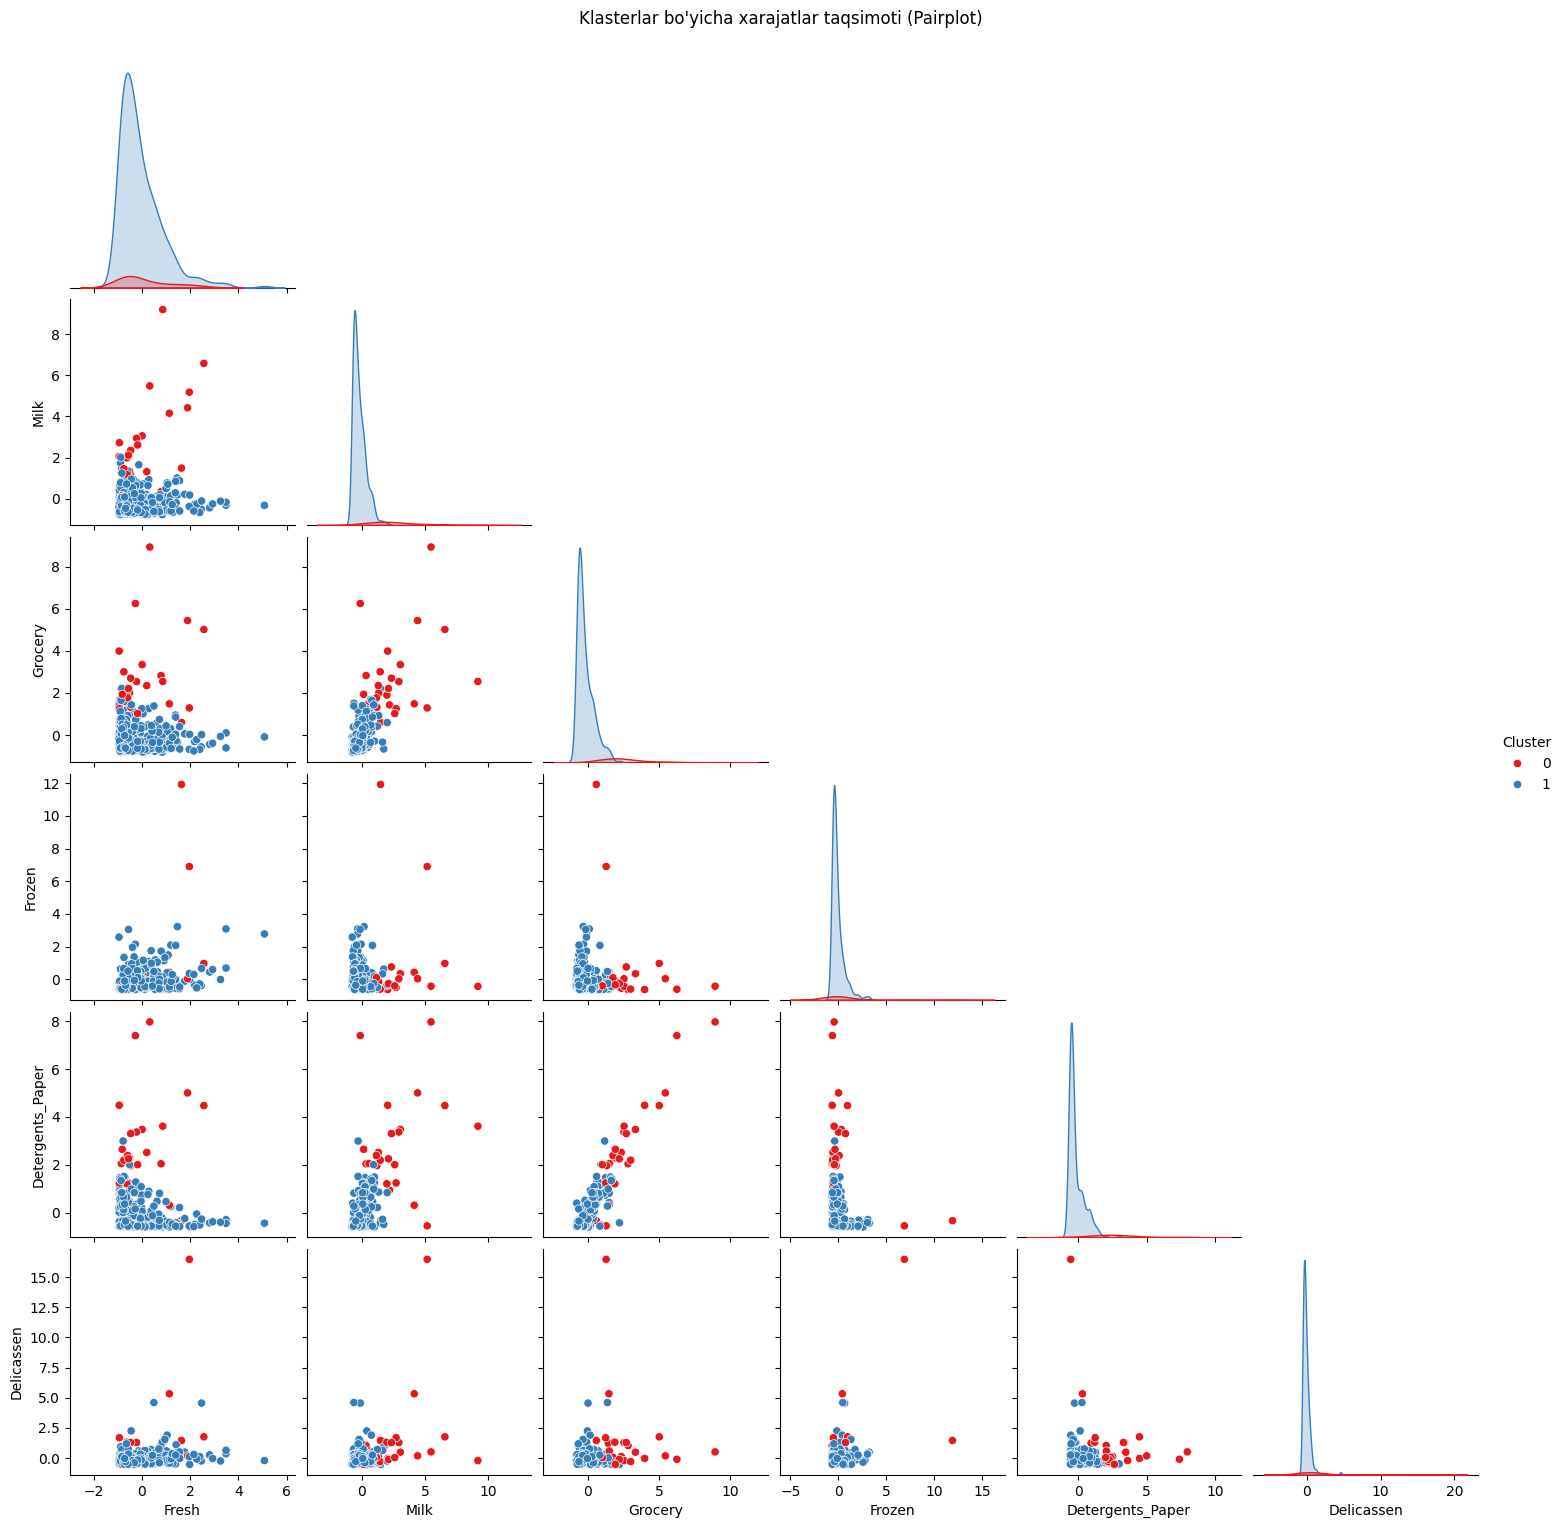

In [28]:
# 1. X_train nusxasini olib, klaster yorliqlarini qo'shamiz
X_train_df = X_train.copy()
X_train_df['Cluster'] = model.labels_

# 2. Pairplot chizamiz
sns.pairplot(X_train_df, hue='Cluster', palette='Set1', corner=True)
plt.suptitle("Klasterlar bo'yicha xarajatlar taqsimoti (Pairplot)", y=1.02)
plt.show()

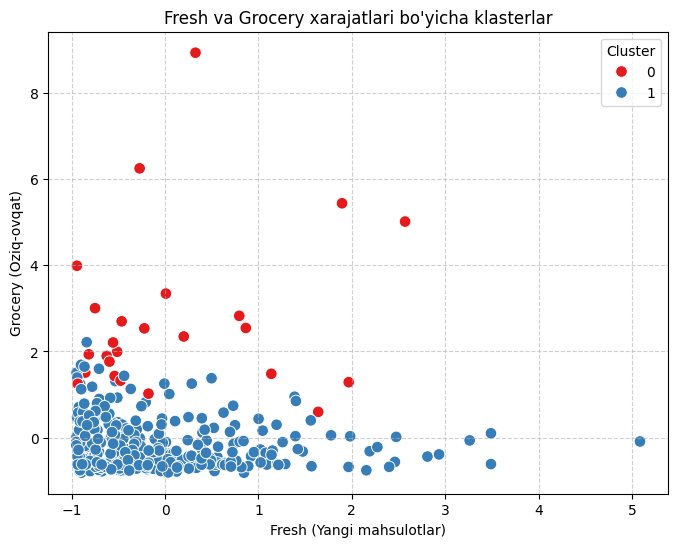

In [29]:
# 1. X_train nusxasiga klasterlarni qo'shamiz (agar yuqoridagi qadam bajarilmagan bo'lsa)
X_train_df = X_train.copy()
X_train_df['Cluster'] = model.labels_

# 2. Scatter plot chizamiz (x va y uchun xohlagan xarajat ustunini tanlashingiz mumkin)
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=X_train_df,
    x='Fresh',
    y='Grocery',
    hue='Cluster',
    palette='Set1',
    s=70
)

plt.title("Fresh va Grocery xarajatlari bo'yicha klasterlar")
plt.xlabel("Fresh (Yangi mahsulotlar)")
plt.ylabel("Grocery (Oziq-ovqat)")
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()